In [1]:
from bookworm import run_bookworm
import own_Tokenizer, own_tfidf
import evaluate
import matplotlib.pyplot as plt


In [2]:
target ="11"

In [ ]:
run_bookworm(action_type="lexdiv", target=target)

In [ ]:
run_bookworm(action_type="topics", target=target)

In [ ]:
run_bookworm(action_type="entities", target=target)

In [ ]:
run_bookworm(action_type="summarize", target=target)


In [9]:
run_bookworm(action_type="similar", target=target )

['Through the Looking-Glass',
 'The Memoirs of Sherlock Holmes',
 'Treasure Island',
 'The Adventures of Sherlock Holmes',
 'The Time Machine']

Evaluation du similar

In [6]:
similar_own = run_bookworm(action_type="similar", target=target, own=True)
similar= run_bookworm(action_type="similar", target=target)

In [5]:
result_similar = evaluate.compare_resulte(own_result=similar_own,ref_result=similar)
print(result_similar)

{'Precision_model': 80.0, 'Precision_ref': 80.0, 'F1_score': 80.0, 'Total_Token_own': 5, 'Total_Token_ref': 5}


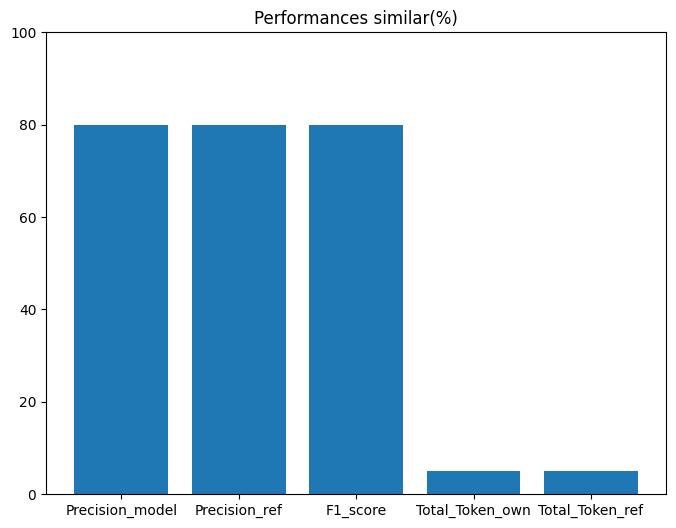

In [5]:
plt.figure(figsize=(8,6))
plt.bar(result_similar.keys(),result_similar.values())
plt.ylim(0,100)
plt.title("Performances similar(%)")

plt.show()

Evaluation du topics

In [10]:
topics_own = run_bookworm(action_type="topics", target=target, own=True)
topics= run_bookworm(action_type="topics", target=target)
print (topics_own)
print(topics)

{'1': ['alice', 'little', 'rabbit', 'key', 'way', 'eat', 'bats', 'like', 'think', 'either'], '2': ['mouse', 'alice', 'pool', 'little', 'cats', 'oh', 'swam', 'dear', 'said', 'mabel'], '3': ['said', 'mouse', 'dodo', 'alice', 'race', 'lory', 'prizes', 'dry', 'thimble', 'know'], '4': ['alice', 'bill', 'little', 'window', 'rabbit', 'puppy', 'gloves', 'chimney', 'one', 'bottle'], '5': ['caterpillar', 'said', 'alice', 'pigeon', 'serpent', 'youth', 'eggs', 'father', 'size', 'little'], '6': ['said', 'alice', 'footman', 'cat', 'baby', 'mad', 'duchess', 'pig', 'wow', 'like'], '7': ['hatter', 'dormouse', 'said', 'alice', 'march', 'hare', 'tea', 'twinkle', 'time', 'well'], '8': ['queen', 'said', 'alice', 'king', 'gardeners', 'soldiers', 'hedgehog', 'cat', 'five', 'executioner'], '9': ['turtle', 'said', 'mock', 'alice', 'gryphon', 'duchess', 'moral', 'queen', 'went', 'school'], '10': ['turtle', 'mock', 'gryphon', 'said', 'dance', 'alice', 'soup', 'join', 'beautiful', 'whiting'], '11': ['king', 'hatt

In [11]:
result_topics = {}

for chapter, word_own in topics_own.items():
    word_ref = topics[chapter]
    scores = evaluate.compare_resulte(word_own , word_ref)
    result_topics[f"ch :{chapter}"]= scores

print(result_topics)


{'ch :1': {'Precision_model': 90.0, 'Precision_ref': 90.0, 'F1_score': 90.0, 'Total_Token_own': 10, 'Total_Token_ref': 10}, 'ch :2': {'Precision_model': 90.0, 'Precision_ref': 90.0, 'F1_score': 90.0, 'Total_Token_own': 10, 'Total_Token_ref': 10}, 'ch :3': {'Precision_model': 100.0, 'Precision_ref': 100.0, 'F1_score': 100.0, 'Total_Token_own': 10, 'Total_Token_ref': 10}, 'ch :4': {'Precision_model': 80.0, 'Precision_ref': 80.0, 'F1_score': 80.0, 'Total_Token_own': 10, 'Total_Token_ref': 10}, 'ch :5': {'Precision_model': 100.0, 'Precision_ref': 100.0, 'F1_score': 100.0, 'Total_Token_own': 10, 'Total_Token_ref': 10}, 'ch :6': {'Precision_model': 100.0, 'Precision_ref': 100.0, 'F1_score': 100.0, 'Total_Token_own': 10, 'Total_Token_ref': 10}, 'ch :7': {'Precision_model': 90.0, 'Precision_ref': 90.0, 'F1_score': 90.0, 'Total_Token_own': 10, 'Total_Token_ref': 10}, 'ch :8': {'Precision_model': 90.0, 'Precision_ref': 90.0, 'F1_score': 90.0, 'Total_Token_own': 10, 'Total_Token_ref': 10}, 'ch :9

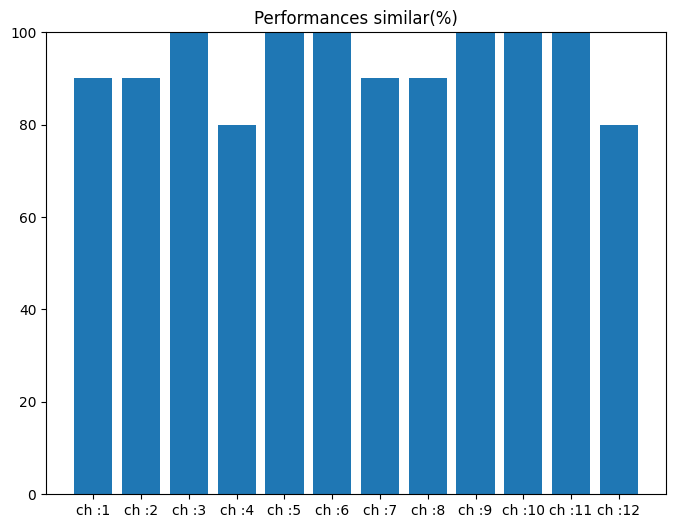

In [12]:
f1 = [scores["F1_score"] for scores in result_topics.values()]
precision =[scores["Precision_model"] for scores in result_topics.values()]


plt.figure(figsize=(8,6))
plt.bar(result_topics.keys(),f1)
plt.ylim(0,100)
plt.title("Performances similar(%)")

plt.show()